In [88]:
import pandas as pd
value_system_df = pd.read_csv('2026-02-02_ess_value_system.csv', sep=',', na_values=[''], quotechar='"')
value_system_df

,country,P__Universalism__Universalism,P__Universalism__Benevolence,P__Universalism__Tradition,P__Universalism__Conformity,P__Universalism__Security,P__Universalism__Power,P__Universalism__Achievement,P__Universalism__Hedonism,P__Universalism__Stimulation,...,VA__Achievement__lgbt_adopt,VA__Hedonism__immigration,VA__Hedonism__lgbt_freedom,VA__Hedonism__lgbt_adopt,VA__Stimulation__immigration,VA__Stimulation__lgbt_freedom,VA__Stimulation__lgbt_adopt,VA__Self-Direction__immigration,VA__Self-Direction__lgbt_freedom,VA__Self-Direction__lgbt_adopt
0,AT,0.5,0.560350,0.296781,0.277517,0.493449,0.113519,0.260402,0.324114,0.060350,...,-0.028641,0.019490,-0.011192,-0.003466,0.605632,-0.347792,-0.107690,-0.243284,0.139709,0.043259
1,BE,0.5,0.558574,0.374808,0.270656,0.376942,0.058574,0.239303,0.380636,0.193998,...,-0.087920,-0.094143,0.065554,0.037635,0.320609,-0.223247,-0.128167,-0.202117,0.140739,0.080799
2,BG,0.5,0.616116,0.484343,0.430800,0.629903,0.137437,0.452282,0.184087,0.129903,...,-0.057211,0.436852,0.001186,0.188757,0.551861,0.001498,0.238450,0.118366,0.000321,0.051144
3,CH,0.5,0.563144,0.321812,0.181475,0.368729,0.063144,0.196526,0.379109,0.160612,...,-0.056834,-0.125697,0.079617,0.025510,0.359852,-0.227934,-0.073031,-0.374123,0.236973,0.075927
4,CY,0.5,0.530362,0.444315,0.225904,0.529005,0.030362,0.150904,0.149160,0.053230,...,0.139325,0.312418,-0.056618,0.140931,0.508189,-0.092096,0.229243,-0.218342,0.039569,-0.098494
5,CZ,0.5,0.523447,0.368886,0.366486,0.652021,0.239894,0.195749,0.289466,0.152021,...,0.074510,0.196912,-0.066993,0.036753,0.493587,-0.167926,0.092127,-0.298447,0.101536,-0.055705
6,DE,0.5,0.555028,0.325689,0.202032,0.396866,0.055028,0.184108,0.319852,0.132145,...,-0.101028,-0.014926,0.009735,0.005259,0.402200,-0.262320,-0.141715,-0.327713,0.213739,0.115470
7,DK,0.5,0.602999,0.307447,0.352956,0.352181,0.102999,0.201948,0.408895,0.217549,...,-0.131544,-0.127449,0.095295,0.050432,0.297765,-0.222642,-0.117826,-0.259802,0.194256,0.102804
8,EE,0.5,0.524932,0.323268,0.292225,0.464926,0.024932,0.152262,0.235762,0.134699,...,0.101117,0.158790,-0.029985,0.046629,0.383374,-0.072394,0.112578,-0.248783,0.046979,-0.073055
9,ES,0.5,0.527518,0.392539,0.293390,0.450837,0.027518,0.132113,0.275518,0.153560,...,-0.225304,0.092816,-0.063846,-0.050820,0.363833,-0.250271,-0.199209,-0.227940,0.156794,0.124804


## Notes

- "Immigration" means "Immigration bad or good for country's economy", where a higher value means **good**.
- "lgbt_freedom" means "Gay men and lesbians should be free to live life as they wish", where a higher value means **yes**
- "lgbt_adopt" means "Gay men and lesbians should have the same rights to adopt children as straight couples", where a higher value means **yes**

- If no country is specified, plots are over **all** countries

## Step 1: Understand the relationship of action judgements
- An action judgement states: If the action is taken, then to what extent will my value be promoted or demoted? (In the opinion of the agent)

### Key Conclusions
- Polarising actions have very strong, differing promotion and demotion between agents. We can see that Immigration is the most polarising action.

- Over all agents, "Immigration" shows a medium-strength correlation between certain values and actions. There are more extreme views portrayed, showing an increased level of polarisation.
- For LGBT rights and adoption, there is no strong correlation between actions and values. There is no overall trend, and the actions are not very polarising.

In [89]:
# Find all columns that start with "P__"
pref_cols = pd.DataFrame(value_system_df.filter(regex="^P__"))
# Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
for col in pref_cols.columns:
    col_split = col.split("__")
    if len(col_split) == 3 and col_split[1] == col_split[2]:
        pref_cols = pref_cols.drop(col, axis=1)
    else:
        # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
        symmetrical_col = "P__"+ col_split[2] + "__" + col_split[1]
        if col in pref_cols.columns:
            pref_cols = pref_cols.drop(columns=[symmetrical_col], axis=1)

In [90]:
stds = pref_cols.std()
stds = stds.sort_values(ascending=True)
print("Standard Deviations for each comparison: \n", stds)

Standard Deviations for each comparison: 
 P__Universalism__Benevolence       0.033759
P__Universalism__Self-Direction    0.041197
P__Universalism__Stimulation       0.052320
P__Benevolence__Self-Direction     0.054438
P__Benevolence__Stimulation        0.054482
P__Conformity__Power               0.058033
P__Stimulation__Self-Direction     0.059965
P__Universalism__Tradition         0.062781
P__Tradition__Security             0.063166
P__Universalism__Power             0.065508
P__Tradition__Achievement          0.065853
P__Power__Self-Direction           0.067815
P__Tradition__Power                0.069179
P__Tradition__Conformity           0.069932
P__Universalism__Conformity        0.071217
P__Security__Power                 0.075887
P__Benevolence__Power              0.076688
P__Conformity__Achievement         0.077470
P__Power__Achievement              0.078639
P__Benevolence__Conformity         0.078673
P__Benevolence__Tradition          0.079432
P__Security__Achievement         

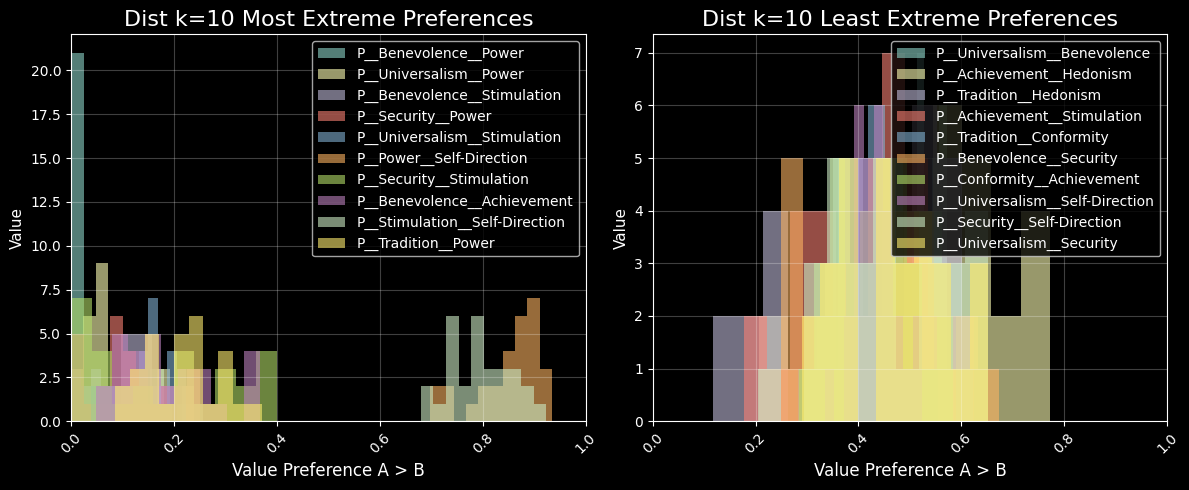

In [91]:
# There are 45 pairwise comparisons, look at top 10 for each (most nothing, most strong)
import matplotlib.pyplot as plt
k = 10
# Find cols that have a mean closest to 0 or 1, find the absolute difference to either 0 or 1 (depending on which side of 0.5 they're on), and then rank the distances
high_means = pref_cols.mean(axis=0).sort_values(ascending=False)
low_means = pref_cols.mean(axis=0).sort_values(ascending=True)
# Clip values
high_means = high_means.clip(lower=0.5, upper=1.0)
low_means = low_means.clip(lower=0.0, upper=0.5)
# Find diff
high_means = 1 - high_means
# Concat
means = pd.concat([high_means, low_means])
means = means.sort_values(ascending=True)

means_keys_high = means.keys().tolist()[:k]
#print("High keys: ", means_keys_high)
means = means.sort_values(ascending=False)
means_keys_low = means.keys().tolist()[:k]
#print("Low keys: ", means_keys_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

for col in means_keys_high:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[0])
axes[0].set_title(f"Dist k={k} Most Extreme Preferences", fontsize=16)
axes[0].set_xlabel('Value Preference A > B', fontsize=12)
axes[0].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(0, 1)

for col in means_keys_low:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[1])
axes[1].set_title(f"Dist k={k} Least Extreme Preferences", fontsize=16)
axes[1].set_xlabel('Value Preference A > B', fontsize=12)
axes[1].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Notes on Value Preferences
- What happens to the performance of value aggregators when we remove the "noise" of indifferent value preferences?
- Are the extreme value preferences reflected in our actions? Are more extreme opinions on the actions shared by agents with more extreme value preferences?

**Values in Extreme Preferences suggest:**
- *Strong preference for:* **Power**, Stimulation, Achievement
- *Strong Preference against:* Tradition, Self-Direction, Benevolence, Security, Stimulation, **Power**

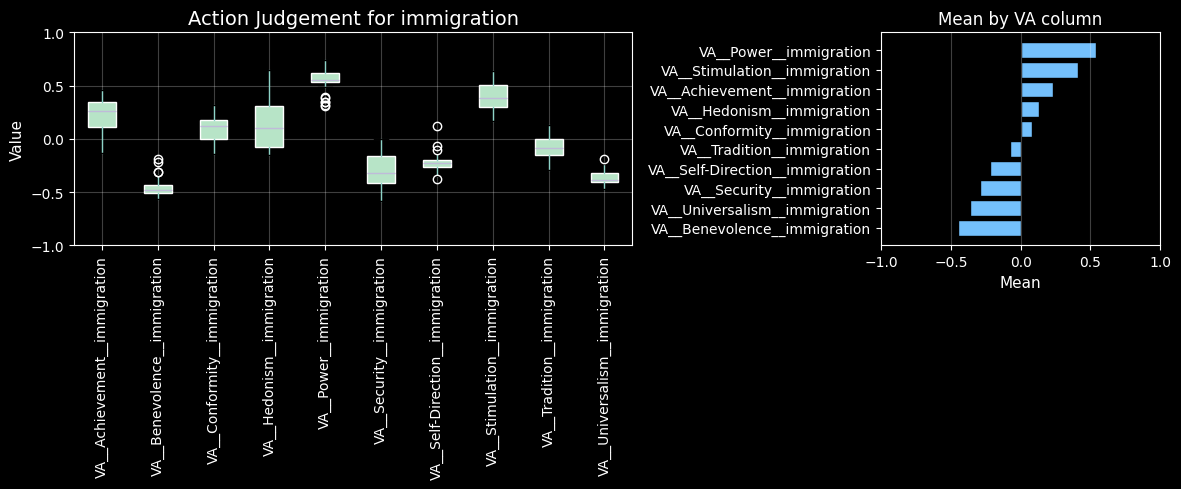

In [92]:
import re
import matplotlib.pyplot as plt

def _va_cols_for_topic(df, topic: str):
    # Get all VA columns for a given topic
    pattern = re.compile(rf"^VA__.*__{re.escape(topic)}$", flags=re.IGNORECASE)
    return [c for c in df.columns if pattern.match(c)]

def plot_va_topic(df, topic: str, figsize=(12, 5)):
    # Plot VA boxplot and mean by VA column for a given topic
    cols = _va_cols_for_topic(df, topic)
    if not cols:
        raise ValueError(f"No VA columns found for topic '{topic}'. Expected columns like 'VA__<Value>__{topic}'.")
    cols = sorted(cols)

    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [2, 1]})

    df[cols].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor="#b7e4c7"))
    axes[0].set_title(f"Action Judgement for {topic}", fontsize=14)
    axes[0].set_ylabel("Value", fontsize=11)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].set_ylim(-1, 1)
    axes[0].grid(alpha=0.25)

    means = df[cols].mean(numeric_only=True).sort_values(ascending=False)
    axes[1].barh(means.index, means.values, color="#74c0fc", edgecolor="black")
    axes[1].set_title("Mean by VA column", fontsize=12)
    axes[1].set_xlabel("Mean", fontsize=11)
    axes[1].invert_yaxis()
    axes[1].set_xlim(-1, 1)
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_va_topic(value_system_df, "immigration")

### Notes: Immigration is good for the economony Action
- Medium-Strength (+/- 0.5) matching Schwartz Values
    - Self-Direction, Stimulation, Power, Benevolence, Universalism

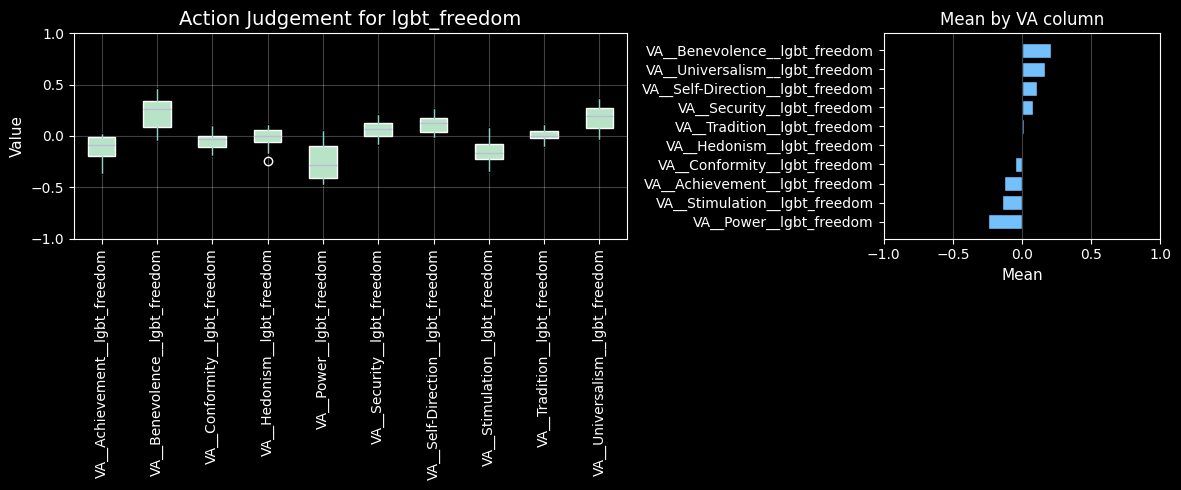

In [93]:
plot_va_topic(value_system_df, "lgbt_freedom")

### Notes: LGBT Rights Action
- Low-Strength correlation between values and actions, with a few agents having stronger correlations.
- No overall large trend.

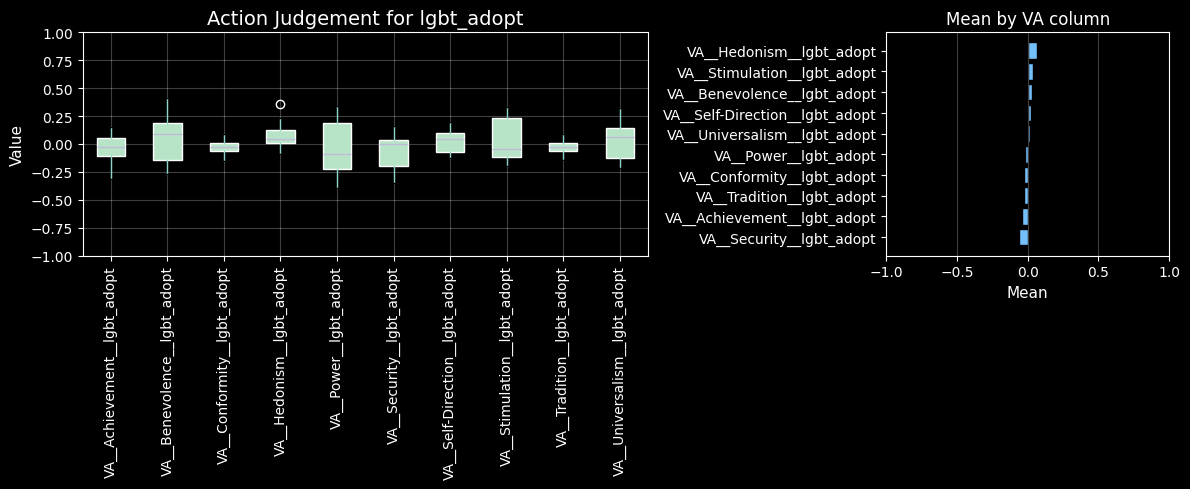

In [94]:
plot_va_topic(value_system_df, "lgbt_adopt")


### Notes: LGBT Adoption Action
- Low-Strength correlation with no extreme positions within the entire group.

### K-Means clustering/PCA analysis to find clusters of agents with similar action judgements
- Here we are looking to find distinct clusters. An ideal scenario would be i) one large cluster, with a small opposing cluster ii) two strongly opposing clusters of similar size. iii) No clear clusters.

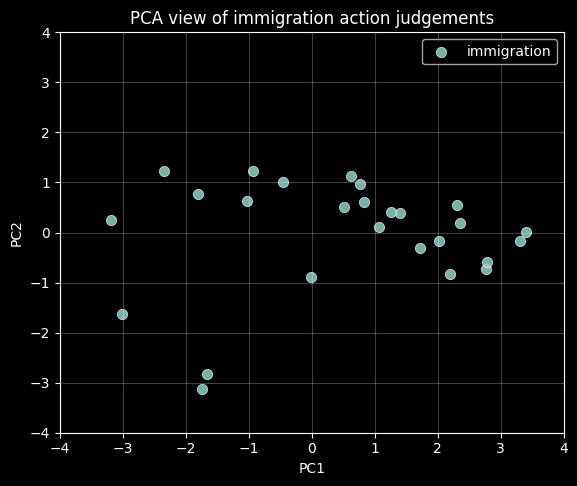

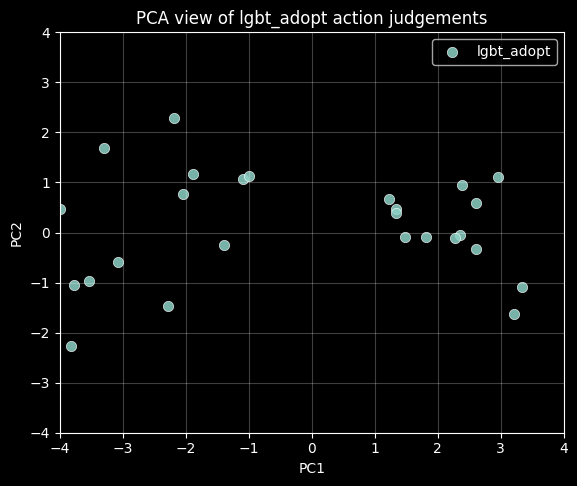

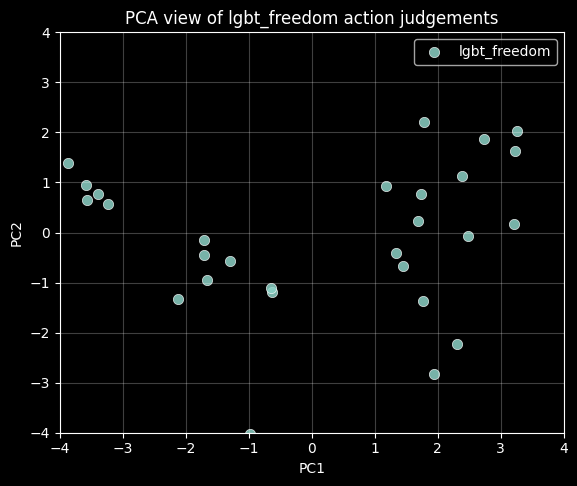

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _va_cols_for_action(df: pd.DataFrame, action: str):
    suffix = f"__{action}"
    return [c for c in df.columns if c.startswith("VA__") and c.endswith(suffix)]

def PCA_per_action(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = sorted(_va_cols_for_action(df, action))
        scaler = StandardScaler()
        # take col data, and scale between 0-1, std 1, for PCA
        X = df[cols].to_numpy(dtype=float)
        X = scaler.fit_transform(X)
        pca_output = PCA(n_components=2).fit_transform(X)

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(pca_output[:, 0], pca_output[:, 1], s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"PCA view of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.grid(alpha=0.25)
        plt.legend(frameon=True)

PCA_per_action(value_system_df)

In [ ]:
## K Means Clustering per action

def k_means_actions(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):


### Step 3: Connection between principles and personal values

### Step 4: Correlation with real support/disagreement and decision made by an agent's PVS